In [1]:
import numpy as np
from seaborn import kdeplot
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [26]:
budget = 4 ** 8
conditioning_list = [4 ** i for i in range(9)]

wds_nn = np.zeros((10, len(conditioning_list)))
wds_mcmc = np.zeros((10, len(conditioning_list)))
wds_nn_std = np.zeros((10, len(conditioning_list)))
wds_mcmc_std = np.zeros((10, len(conditioning_list)))
for i in range(1,11):
    output_root = "budget_results"
    output_dir = os.path.join(output_root, f"ode_{i}")
    wd_nn_array = np.load(os.path.join(output_dir, "wd_nn_array_mean.npy"))
    wd_mcmc_array = np.load(os.path.join(output_root, f"wd_mcmc_array_mean_{i}.npy"))
    wd_nn_std = np.load(os.path.join(output_dir, "wd_nn_array_std.npy"))
    wd_mcmc_std = np.load(os.path.join(output_root, f"wd_mcmc_array_std_{i}.npy"))

    wds_nn[i-1, :] = wd_nn_array
    wds_mcmc[i-1, :] = wd_mcmc_array
    wds_nn_std[i-1, :] = wd_nn_std
    wds_mcmc_std[i-1, :] = wd_mcmc_std

In [29]:
wd_means = np.mean(wds_nn, axis=0)
wd_stds = np.mean(wds_nn_std, axis=0)

In [30]:
wd_mcmc_means = np.mean(wds_mcmc, axis=0)
wd_mcmc_stds = np.mean(wds_nn_std, axis=0)

Text(0, 0.5, 'W2 Error')

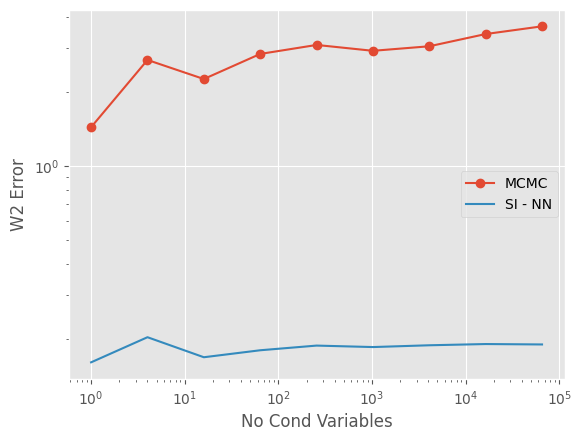

In [39]:
plt.plot(conditioning_list, wd_mcmc_means, label="MCMC", marker="o")
plt.plot(conditioning_list, wd_means * np.ones(9), label="SI - NN")
# plt.axhline(np.mean(wd_nn_array).item(), label="SI")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("No Cond Variables")
plt.ylabel("W2 Error")

In [41]:
wds_mcmc

array([[0.05652871, 2.52728828, 2.08406845, 2.67168709, 3.11635083,
        2.92668324, 3.04463174, 3.40401451, 3.67125984],
       [0.13361706, 2.63855557, 1.61561494, 2.49577759, 2.97356386,
        2.95498489, 3.00683223, 3.42999683, 3.67119166],
       [0.03983911, 4.04129417, 2.74379434, 3.24532317, 3.16809358,
        2.96293548, 3.0394921 , 3.41100943, 3.66714207],
       [0.02684289, 2.34341695, 2.41768566, 3.42720657, 3.04650621,
        3.01486593, 3.06560007, 3.39863494, 3.66711502],
       [6.08455281, 0.05264203, 2.07592555, 2.75740923, 3.06468064,
        2.87839885, 3.01072606, 3.41360207, 3.65907332],
       [1.09039426, 3.8005348 , 1.73079726, 3.19529928, 3.03059668,
        2.8122308 , 3.1035986 , 3.41133754, 3.67932256],
       [0.03632746, 4.13053106, 3.59657767, 3.06988236, 3.18226239,
        2.91084744, 3.06524453, 3.44248117, 3.66966868],
       [0.03952286, 1.36945018, 1.8192379 , 2.42189387, 3.34666619,
        2.87491349, 3.03366195, 3.41185343, 3.68229198],


In [46]:
np.load("mcmc_results/mcmc_results_1/cond_vars_1.npy")

array([-0.73665051])

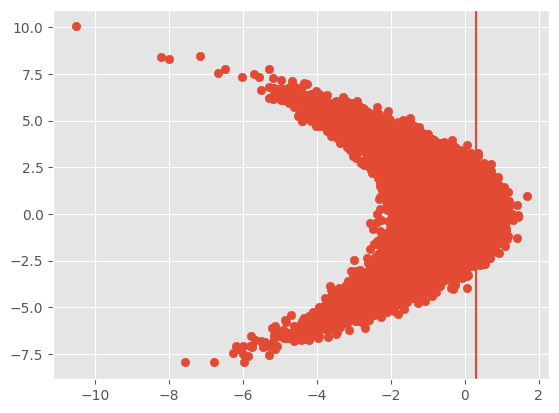

In [15]:
from triangular_transport.flows.methods.sampling import inf_train_gen
target_data = inf_train_gen(data="banana", rng=None, batch_size=budget)
plt.scatter(target_data[:, 0], target_data[:, 1])
plt.axvline(0.3)

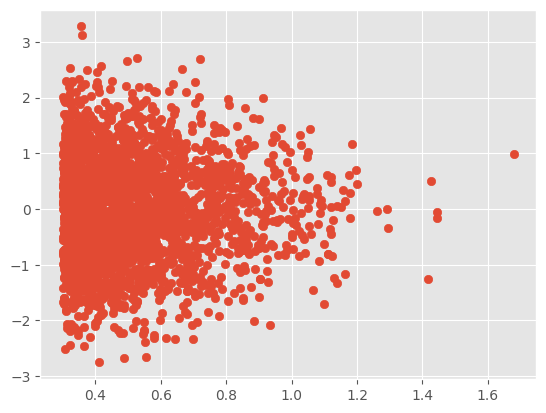

In [16]:
sub_data = target_data[np.where(target_data[:, 0] >= 0.3)[0]]
plt.scatter(sub_data[:, 0], sub_data[:, 1])

In [77]:
np.where(target_data[:, 0] >= 1.0)

(array([  200,  2304,  3889,  3964,  4859,  6934,  8541, 10894, 10989,
        11388, 11709, 13494, 15805, 16100, 16431, 17925, 18311, 19279,
        19826, 21210, 21255, 21778, 22481, 23786, 23842, 24328, 24884,
        25576, 26303, 26701, 30114, 30164, 30565, 31000, 31792, 32115,
        34320, 34836, 35196, 35322, 36159, 38090, 38249, 39510, 42396,
        43822, 46412, 46687, 46711, 46790, 47014, 48250, 48351, 49342,
        50649, 51254, 51893, 52166, 54206, 55660, 56929, 57522, 59152,
        60902, 61018, 62442, 62987, 63521]),)

In [76]:
np.max(target_data[:, 0])

np.float64(1.6780082795173554)

In [69]:
cond_vars[49]

np.float64(1.5765588923716285)

In [71]:
cond_vars[36]

np.float64(1.7298035568642156)